# Box model using ATom data - including HOx interconversion reactions
This notebook contains calculations for the zero-dimensional box model with an extended set of inputs.

It follows the same procedure as the calculations with the minimal set of inputs, but with additional source and sink reactions.

These reactions are:

Sources:

$HO_2 + NO → OH + NO_2$

$HO_2 + O_3 → OH + 2O_2$

Sinks:

$OH + O_3 → HO_2 + O_2$

$OH + HO_2 → H_2O + O_2$

$OH + HNO_3 → H_2O + NO_2$

The updated equation for $[OH]$ is now:

$[OH]_{ss}=\frac{2k_1[O(^1D)][H_2O] + k_5[HO_2][NO] + k_6[HO_2][O_3]}{k_2[CO] + k_3[CH_4] + k_7[O_3] + k_8[HO_2] + k_9[HNO_3]}$

---

In [ ]:
import pandas as pd
from datetime import datetime, timezone
import numpy as np
from pytz import timezone
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pytz
import sklearn
from sklearn import metrics
# If cartopy is not installed, run this
# !pip install cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("MDS_atom1_2016_summer_with_no_no2_oh_ho2_full_js.csv")

In [4]:
df = df[['Temp', 'Pres','UTC_Start_dt', 'lat', 'lon', 'Altitude', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'OH_ATHOS', 'HO2_ATHOS', 'CO_M', 'CH4_M', 'PAN_M', 'NOX_M', 'NO_CL', 'HNO3_M']]
df

,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,HO2_ATHOS,CO_M,CH4_M,PAN_M,NOX_M,NO_CL,HNO3_M
0,249.265,343.334,2016-07-29 14:56:10,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,6.444,7.233967e-08,0.000002,2.855530e-10,9.948500e-11,0.063649,3.272000e-10
1,248.771,337.478,2016-07-29 14:56:40,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,5.367,6.900650e-08,0.000002,2.855530e-10,9.693500e-11,0.063389,3.104400e-10
2,248.851,331.741,2016-07-29 14:57:10,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,4.633,7.108760e-08,0.000002,2.855530e-10,9.569200e-11,0.074402,3.491900e-10
3,246.160,315.391,2016-07-29 14:58:40,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,6.063,6.804040e-08,0.000002,2.855530e-10,9.645400e-11,0.073041,3.308700e-10
4,245.201,309.998,2016-07-29 14:59:10,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,6.233,6.748330e-08,0.000002,2.855530e-10,1.144770e-10,0.069717,2.892000e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6545,287.376,734.283,2016-08-23 19:51:00,34.94797,242.36580,2818.77,0.000048,5.419620e-08,0.007266,0.227,43.328,1.485790e-07,0.000002,2.055130e-10,4.076800e-11,0.010443,1.799500e-10
6546,288.683,749.875,2016-08-23 19:51:30,34.91515,242.35962,2641.88,0.000047,5.082710e-08,0.007460,0.227,43.173,1.320212e-07,0.000002,2.055130e-10,4.127300e-11,0.014422,1.794200e-10
6547,290.545,771.085,2016-08-23 19:52:00,34.88332,242.34174,2403.69,0.000046,5.125980e-08,0.007838,0.240,43.017,1.325316e-07,0.000002,2.055130e-10,7.323400e-11,0.015064,1.858900e-10
6548,291.259,777.013,2016-08-23 19:52:30,34.85163,242.32323,2339.75,0.000046,5.167830e-08,0.007777,0.240,48.457,1.355386e-07,0.000002,2.055130e-10,7.178500e-11,0.021050,1.843600e-10


In [5]:

df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['UTC_Start_dt'] = df['UTC_Start_dt'].dt.tz_localize('UTC')
df["UTC_Start_dt"] = df["UTC_Start_dt"].dt.tz_convert('America/New_York')
df['date'] = df['UTC_Start_dt']
df['date']

0      2016-07-29 10:56:10-04:00
1      2016-07-29 10:56:40-04:00
2      2016-07-29 10:57:10-04:00
3      2016-07-29 10:58:40-04:00
4      2016-07-29 10:59:10-04:00
                  ...           
6545   2016-08-23 15:51:00-04:00
6546   2016-08-23 15:51:30-04:00
6547   2016-08-23 15:52:00-04:00
6548   2016-08-23 15:52:30-04:00
6549   2016-08-23 15:53:30-04:00
Name: date, Length: 6550, dtype: datetime64[ns, America/New_York]

In [6]:
# Unit conversions
kb = 1.38e-23  # J K^−1 Boltzmann's constant

for i in range(len(df)):
    df.loc[i, "M"] = ((df.loc[i, "Pres"] * 100) / (kb * df.loc[i, "Temp"])) * 1e-6  # molecules cm^3, pressure was in hPa so multiplied by 100 to Pa

df.head()

,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,HO2_ATHOS,CO_M,CH4_M,PAN_M,NOX_M,NO_CL,HNO3_M,date,M
0,249.265,343.334,2016-07-29 10:56:10-04:00,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,6.444,7.233967e-08,0.000002,2.855530e-10,9.948500e-11,0.063649,3.272000e-10,2016-07-29 10:56:10-04:00,9.981054e+18
1,248.771,337.478,2016-07-29 10:56:40-04:00,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,5.367,6.900650e-08,0.000002,2.855530e-10,9.693500e-11,0.063389,3.104400e-10,2016-07-29 10:56:40-04:00,9.830297e+18
2,248.851,331.741,2016-07-29 10:57:10-04:00,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,4.633,7.108760e-08,0.000002,2.855530e-10,9.569200e-11,0.074402,3.491900e-10,2016-07-29 10:57:10-04:00,9.660079e+18
3,246.160,315.391,2016-07-29 10:58:40-04:00,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,6.063,6.804040e-08,0.000002,2.855530e-10,9.645400e-11,0.073041,3.308700e-10,2016-07-29 10:58:40-04:00,9.284376e+18
4,245.201,309.998,2016-07-29 10:59:10-04:00,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,6.233,6.748330e-08,0.000002,2.855530e-10,1.144770e-10,0.069717,2.892000e-10,2016-07-29 10:59:10-04:00,9.161310e+18


## Source rate

**Additional sources being added:**

**$HO_2 + NO → OH + NO_2$**

**source rate = $k_4[HO_2][NO]$**

**$HO_2 + O_3→OH + 2O_2$**

**source rate = $k_5[HO_2][O_3]$**

This now makes the source rate:


$[OH] = 2k_1[O(^1D)][H_2O]) + k_4[HO_2][NO] + k_5[HO_2][O_3]$

In [9]:
df['kH2O'] = 1.63e-10 * np.exp(-(-60/df["Temp"])) ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kM'] = 2.15e-11 * np.exp(-(-110/df["Temp"])) ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

# Additional sources
df['kHO2NO'] = 3.44e-12 * np.exp(-(-260/df["Temp"])) ## page 83 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kHO2O3'] = 1.0e-14 * np.exp(-(490/df["Temp"])) ## page 67 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

# New column for conversion from mole fraction to molecules cm^-3
df["O3"] = df["O3_M"] * df["M"]
df["H2O"] = df["H2O_M"] * df["M"]
df["HO2"] = df["HO2_ATHOS"] * 1e-12 * df["M"]
df["NO"] = df["NO_CL"] * 1e-9 * df["M"]


df["O1D"] = (df["jO3_O2_O1D_CAFS"] * df["O3_M"]) / ((df['kH2O'] * df["H2O_M"]) + (df['kM']))

In [10]:
for i in range(len(df)):
    df.loc[i, "source"] = (2 * df['kH2O'][i] * df["O1D"][i] * df["H2O"][i]) + (df['kHO2O3'][i] * df["HO2"][i] * df["O3"][i]) + (df['kHO2O3'][i] * df["HO2"][i] * df["O3"][i])+ (df['kHO2NO'][i] * df["HO2"][i] * df["NO"][i])  ## Error
print(f"Mean source rate: {df["source"].mean():.2e}") # source should be around 1e6 molecules cm^-3 s^-1

print("Mean contribution to source rates (in molecules cm^-3 s^-1):")
print(f"Mean O1D contribution:  {(2 * df['kH2O'] * df["O1D"] * df["H2O"]).mean():.2e}")
print(f"Mean NO contribution: {(df['kHO2NO'] * df["HO2"] * df["NO"]).mean():.2e}")
print(f"HO2 contribution: {(df['kHO2O3'] * df["HO2"] * df["O3"]).mean():.2e}")

Mean source rate: 1.58e+06
Mean contribution to source rates (in molecules cm^-3 s^-1):
Mean O1D contribution:  7.15e+05
Mean NO contribution: 5.12e+05
HO2 contribution: 1.78e+05


### Check that the source rate constants at 298 K match with literature values

In [12]:
print(f"k for reaction of O1D + H2O: {(1.63e-10 * np.exp(--60/298)):.2e} , lit: 2.0e-10")
print(f"k for reaction of HO2 + NO: {(3.44e-12 * np.exp(--260/298)):.2e}, lit: 8.2e-12")
print(f"k for reaction of HO2 + O3: {(1.0e-14 * np.exp(-490/298)):.2e}, lit: 1.9e-15")

k for reaction of O1D + H2O: 1.99e-10 , lit: 2.0e-10
k for reaction of HO2 + NO: 8.23e-12, lit: 8.2e-12
k for reaction of HO2 + O3: 1.93e-15, lit: 1.9e-15


## Box model equation to find [OH]

## Sink rate coefficient

**Additional sinks being added:**

**$OH + O_3 → HO_2 + O_2$**

**Rate coefficient $k_6[O_3]$**

**$OH + HNO_3 → H_2O + NO_2$**

**Rate coefficient $k_7[HNO_3]$**

**$OH + HO_2 → H_2O + O_2$**

**Rate coefficient $k_8[HO_2]$**

In [16]:
df["P_atm"] = 0.000987 * df["Pres"]
df['kOHCO']  = 1.5e-13  * (1.0 + 0.6 * df["P_atm"]) # where P is the pressure in atmospheres, page 484 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kOHCH4'] = 2.45e-12 * np.exp(-(1775/df['Temp'])) ## page 106 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kOHO3'] = 1.7e-12 * np.exp(-(940/df["Temp"])) ## page 67 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kOHHO2'] = 4.8e-11 * np.exp(-(-250/df["Temp"])) ## page 67 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kOHHNO3'] = 8.28e-14 * (1.0 + 0.6 * df["P_atm"]) ## page 484 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

df["CO"] = df['CO_M'] * df["M"]
df["CH4"] = df['CH4_M'] * df["M"]
df["HNO3"] = df['HNO3_M'] * df["M"]


# Sink contributions
print("Sink rate coefficients (in molecules^-1 cm^3 s^-1):")
print(f"CO contribution: {(df['kOHCO'] * df["CO"]).mean():.2e}")
print(f"CH4 contribution: {(df['kOHCH4'] * df["CH4"]).mean():.2e}")
print(f"O3 contribution: {(df['kOHO3'] * df["O3"]).mean():.2e}")
print(f"HO2 contribution: {(df['kOHHO2'] * df["HO2"]).mean():.2e}")
print(f"HNO3 contribution: {(df['kOHHNO3'][i] * df["HNO3"][i]).mean():.2e}")

Sink rate coefficients (in molecules^-1 cm^3 s^-1):
CO contribution: 2.21e-01
CH4 contribution: 7.67e-02
O3 contribution: 2.80e-02
HO2 contribution: 2.18e-02
HNO3 contribution: 1.32e-03


### Check that the sink rate constants at 298 K match with literature values

In [18]:
print(f"k for reaction of OH + CO: {(1.5e-13  * (1.0 + 0.6 * 1)):.2e}, lit: 2.4e-13")
print(f"k for reaction of OH + CH4: {(2.45e-12 * np.exp(-(1775/298))):.2e}, lit: 6.3e-15")
print(f"k for reaction of OH + O3: {(1.7e-12 * np.exp(-(940/298))):.2e}, lit: 7.3e-14")
print(f"k for reaction of OH + HO2: {(4.8e-11 * np.exp(-(-250/298))):.2e}, lit: 1.1e-10")
print(f"k for reaction of OH + HNO3: {(8.28e-14  * (1.0 + 0.6 * 1)):.2e}, lit: 1.4e-13")

k for reaction of OH + CO: 2.40e-13, lit: 2.4e-13
k for reaction of OH + CH4: 6.34e-15, lit: 6.3e-15
k for reaction of OH + O3: 7.25e-14, lit: 7.3e-14
k for reaction of OH + HO2: 1.11e-10, lit: 1.1e-10
k for reaction of OH + HNO3: 1.32e-13, lit: 1.4e-13


## Finally, calculating $[OH]$

In [20]:
# Calculating [OH]
for i in range(len(df)):
    df.loc[i, "[OH]_calc"] = (df.loc[i, "source"]) / ((df['kOHCO'][i] * df["CO"][i]) + (df['kOHCH4'][i] * df["CH4"][i]) + (df['kOHHNO3'][i] * df["HNO3"][i]) + (df['kOHHO2'][i] * df["HO2"][i]) + (df['kOHO3'][i] * df["O3"][i]))


## Plotting modelled $[OH]_{SS}$ vs measured $[OH]$ from ATom data

In [22]:
df["[OH]_measured"] = df["OH_ATHOS"] * 1e-12 * df["M"] # in ppt

In [23]:
df.mean(numeric_only = True)

Temp               2.514861e+02
Pres               4.785047e+02
lat                1.882980e+01
lon                2.559855e+02
Altitude           6.797287e+03
jO3_O2_O1D_CAFS    3.120396e-05
O3_M               6.662522e-08
H2O_M              3.564000e-03
OH_ATHOS           2.556285e-01
HO2_ATHOS          1.249669e+01
CO_M               8.076784e-08
CH4_M              1.850161e-06
PAN_M              1.234701e-10
NOX_M              6.373149e-11
NO_CL              3.335542e-02
HNO3_M             1.368826e-10
M                  1.329983e+19
kH2O               2.074671e-10
kM                 3.347250e-11
kHO2NO             9.824030e-12
kHO2O3             1.424233e-15
O3                 7.120066e+11
H2O                7.334532e+16
HO2                1.767512e+08
NO                 3.423722e+08
O1D                5.354203e-02
source             1.582926e+06
P_atm              4.722841e-01
kOHCO              1.925056e-13
kOHCH4             2.488722e-15
kOHO3              4.175969e-14
kOHHO2  

In [24]:
df.min(numeric_only = True)

Temp               2.051720e+02
Pres               1.788970e+02
lat               -6.473159e+01
lon                1.695991e+02
Altitude           1.568900e+02
jO3_O2_O1D_CAFS   -9.189799e-08
O3_M               7.215400e-09
H2O_M              3.779000e-06
OH_ATHOS          -3.800000e-02
HO2_ATHOS         -4.650000e-01
CO_M               2.140420e-08
CH4_M              1.704809e-06
PAN_M              3.820000e-13
NOX_M              1.000000e-15
NO_CL             -1.419500e-02
HNO3_M             1.000000e-15
M                  5.997505e+18
kH2O               1.987151e-10
kM                 3.091607e-11
kHO2NO             8.117314e-12
kHO2O3             9.179108e-16
O3                 1.270398e+11
H2O                3.462122e+13
HO2               -1.197578e+07
NO                -1.662546e+08
O1D               -1.689999e-04
source            -5.353090e+04
P_atm              1.765713e-01
kOHCO              1.658914e-13
kOHCH4             4.285128e-16
kOHO3              1.740681e-14
kOHHO2  

In [25]:
df.max(numeric_only = True)

Temp               3.028440e+02
Pres               1.014602e+03
lat                8.000860e+01
lon                3.453674e+02
Altitude           1.314651e+04
jO3_O2_O1D_CAFS    1.302335e-04
O3_M               4.400936e-07
H2O_M              2.929838e-02
OH_ATHOS           1.955000e+00
HO2_ATHOS          5.983500e+01
CO_M               3.348210e-07
CH4_M              2.007818e-06
PAN_M              8.148370e-10
NOX_M              1.002477e-08
NO_CL              3.876647e+00
HNO3_M             2.027320e-09
M                  2.608741e+19
kH2O               2.183693e-10
kM                 3.675185e-11
kHO2NO             1.221544e-11
kHO2O3             1.982959e-15
O3                 3.738807e+12
H2O                7.025532e+17
HO2                1.205935e+09
NO                 8.914994e+10
O1D                3.608973e-01
source             8.207497e+07
P_atm              1.001412e+00
kOHCO              2.401271e-13
kOHCH4             6.977843e-15
kOHO3              7.628492e-14
kOHHO2  

In [26]:
df.std(numeric_only = True)

Temp               2.509002e+01
Pres               2.429320e+02
lat                3.951152e+01
lon                5.813160e+01
Altitude           3.674819e+03
jO3_O2_O1D_CAFS    2.115024e-05
O3_M               6.996312e-08
H2O_M              6.302623e-03
OH_ATHOS           2.324705e-01
HO2_ATHOS          8.769121e+00
CO_M               3.063725e-08
CH4_M              4.346564e-08
PAN_M              1.160524e-10
NOX_M              1.482176e-10
NO_CL              6.959220e-02
HNO3_M             2.495005e-10
M                  5.526755e+18
kH2O               4.924416e-12
kM                 1.456251e-12
kHO2NO             1.009057e-12
kHO2O3             2.752941e-16
O3                 4.960499e+11
H2O                1.442520e+17
HO2                1.637039e+08
NO                 1.201106e+09
O1D                5.058083e-02
source             2.803831e+06
P_atm              2.397739e-01
kOHCO              2.157965e-14
kOHCH4             1.670501e-15
kOHO3              1.533749e-14
kOHHO2  

Comparison plots for 4 days

Text(0.5, 1.0, '06/08/2016 15:00-22:00')

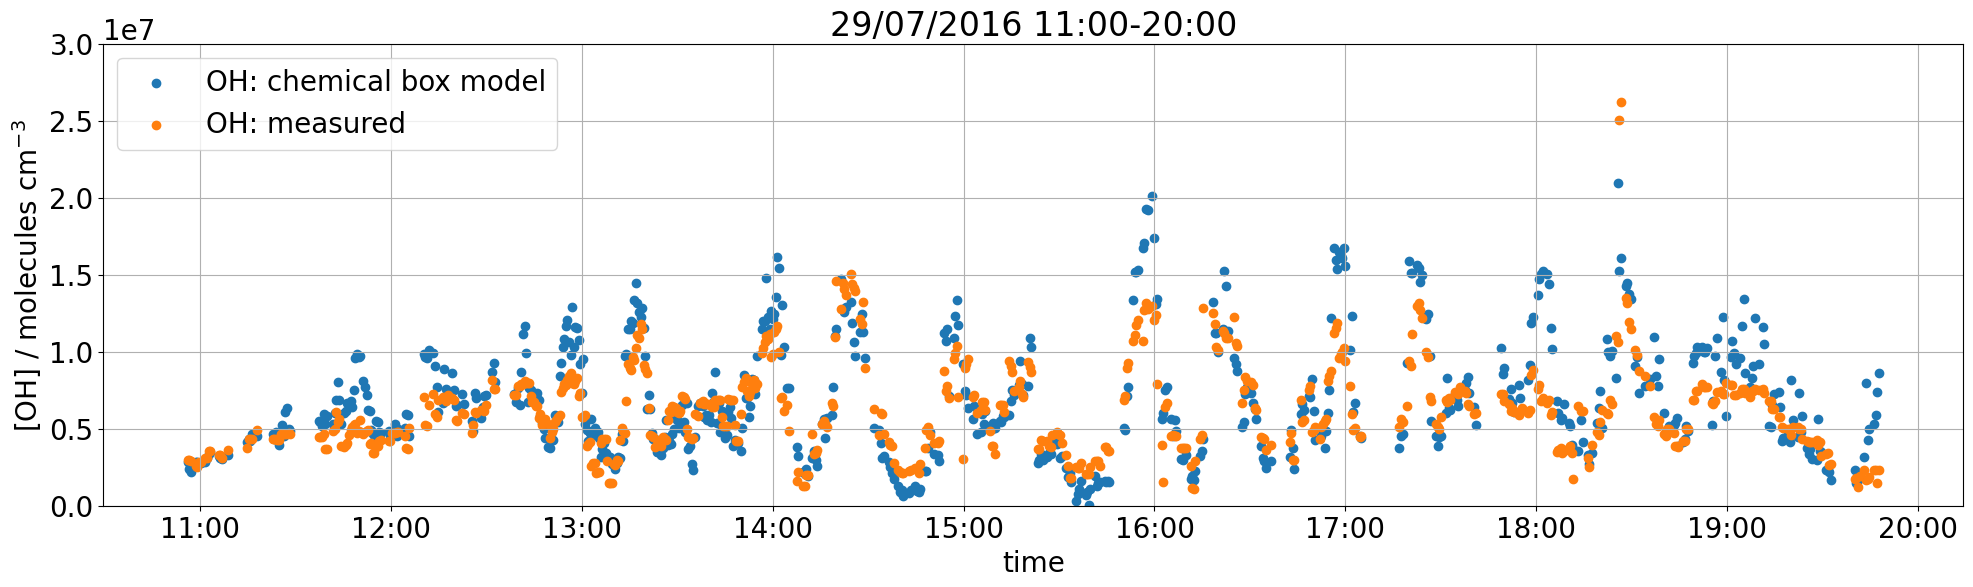

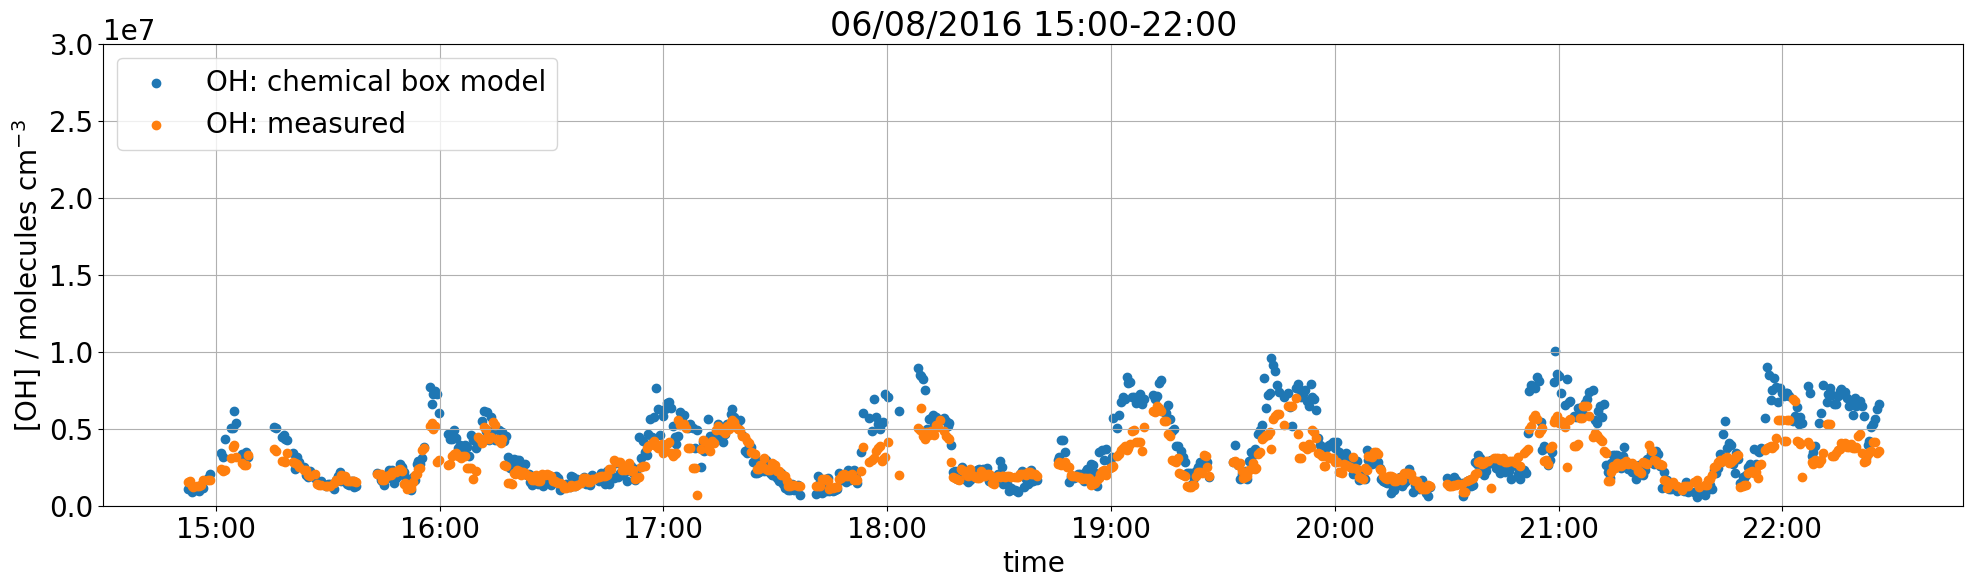

In [28]:

plt.rcParams.update({'font.size':20})
fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "OH: chemical box model")
ax1.set_xlabel("time")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel("[OH] / molecules cm$^{-3}$")
ax1.set_ylim(0, 3e7)
ax1.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_measured"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "OH: measured")
ax1.grid(True)
ax1.legend(loc="upper left")
plt.title("29/07/2016 11:00-20:00")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "OH: chemical box model")
ax1.set_xlabel("time")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel("[OH] / molecules cm$^{-3}$")
ax1.set_ylim(0, 3e7)
ax1.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_measured"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "OH: measured")
ax1.grid(True)

ax1.legend(loc="upper left")
plt.title("06/08/2016 15:00-22:00")

Text(0.5, 1.0, '06/08/2016 15:00-22:00')

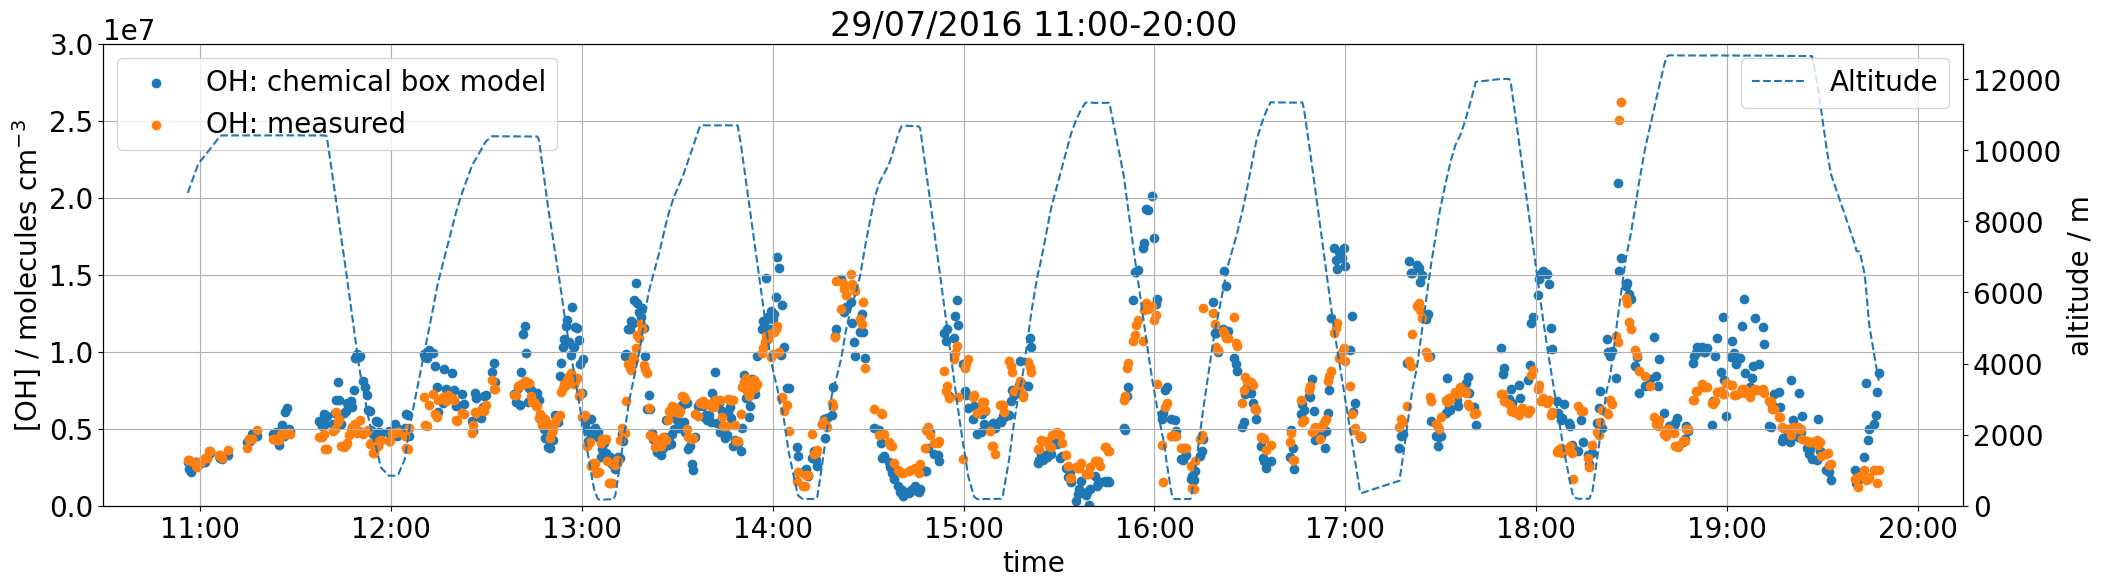

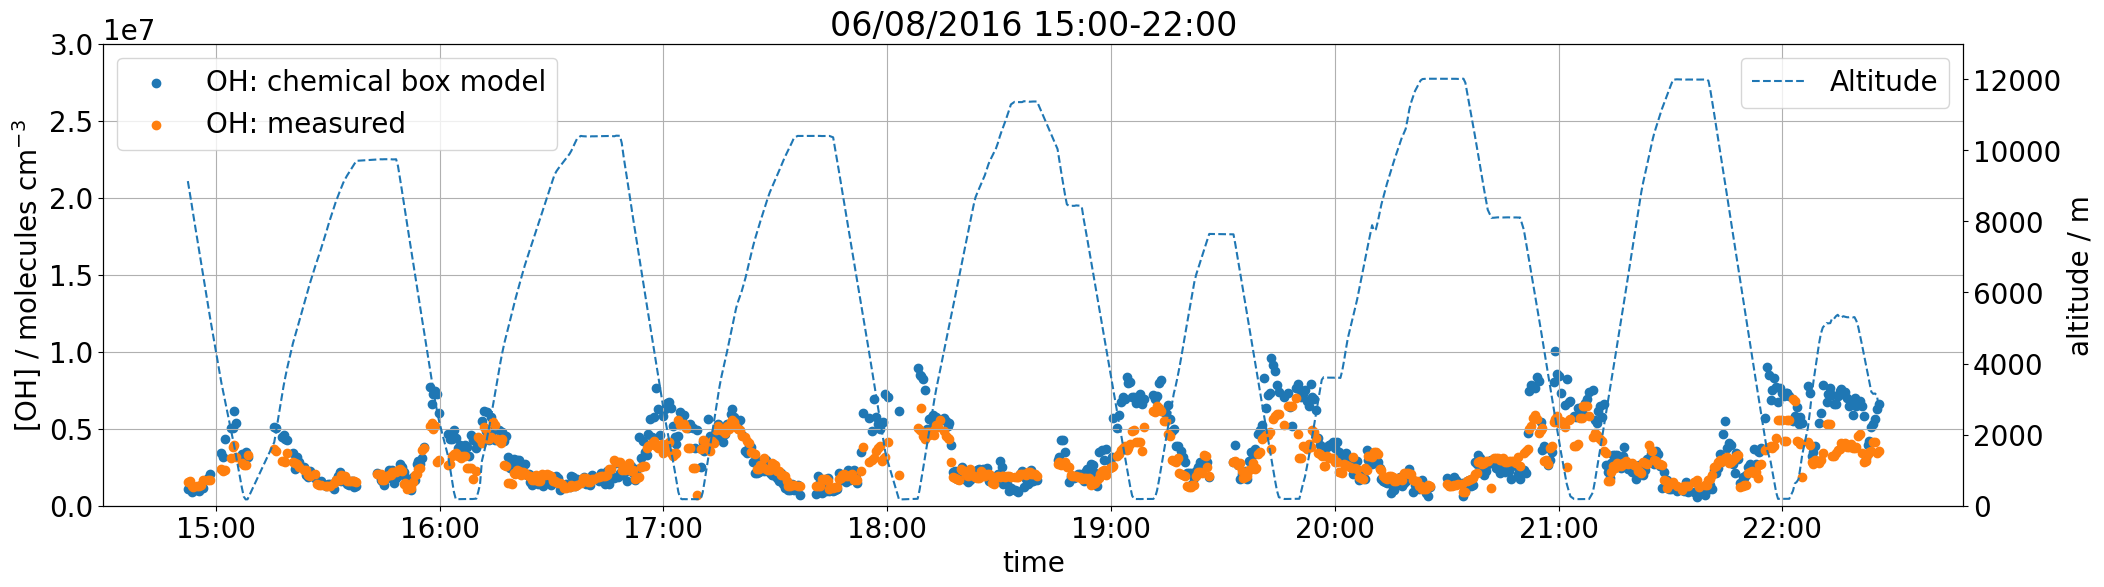

In [29]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':20})
fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "OH: chemical box model")
ax1.set_xlabel("time")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel("[OH] / molecules cm$^{-3}$")
ax1.set_ylim(0, 3e7)
ax1.legend()
ax1.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_measured"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "OH: measured")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], df["Altitude"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], linestyle='--', label = "Altitude")
ax2.set_ylim(0, 13000)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("29/07/2016 11:00-20:00")


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "OH: chemical box model")
ax1.set_xlabel("time")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel("[OH] / molecules cm$^{-3}$")
ax1.set_ylim(0, 3e7)
ax1.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_measured"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "OH: measured")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], df["Altitude"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], linestyle='--', label = "Altitude")
ax2.set_ylim(0, 13000)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("06/08/2016 15:00-22:00")

In [30]:
X = df[["[OH]_measured"]][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")]
y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-08-01")]
print(f"r2 for 28/07/2016: {round(sklearn.metrics.r2_score(X, y), 3)}")
print(f"RMSE for 28/07/2016: {sklearn.metrics.root_mean_squared_error(X, y):.2e} molecules cm^-3")

X = df[["[OH]_measured"]][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")]
y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")]
print(f"r2 for 06/08/2016: {round(sklearn.metrics.r2_score(X, y), 3)}")
print(f"RMSE for 28/07/2016: {sklearn.metrics.root_mean_squared_error(X, y):.2e} molecules cm^-3")

X = df[["[OH]_measured"]]
y = df["[OH]_calc"]
print(f"r2 for whole dataset: {round(sklearn.metrics.r2_score(X, y), 3)}")
print(f"RMSE for whole dataset: {sklearn.metrics.root_mean_squared_error(X, y):.2e}")

r2 for 28/07/2016: 0.356
RMSE for 28/07/2016: 2.34e+06 molecules cm^-3
r2 for 06/08/2016: -0.221
RMSE for 28/07/2016: 1.45e+06 molecules cm^-3
r2 for whole dataset: -0.173
RMSE for whole dataset: 2.81e+06


In [31]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
for i in range(len(numbers) - 1):
    X = df[["[OH]_measured"]][(df["Altitude"] >= int(numbers[i])) & (df["Altitude"] < int(numbers[i + 1]))]
    y = df["[OH]_calc"][(df["Altitude"] >= int(numbers[i])) & (df["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(sklearn.metrics.r2_score(X, y))
    metrics_rmse.append(sklearn.metrics.root_mean_squared_error(X, y))

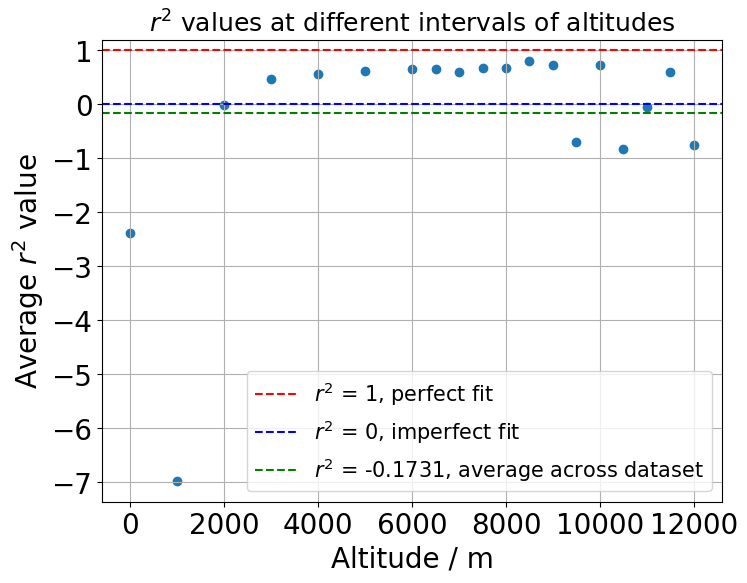

In [32]:
fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (sklearn.metrics.r2_score(df[["[OH]_measured"]], df["[OH]_calc"])), color = 'g', linestyle = '--', label = f'$r^2$ = {round(sklearn.metrics.r2_score(df[["[OH]_measured"]], df["[OH]_calc"]), 4)}, average across dataset')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes")
plt.legend(prop={'size':15})

plt.grid()

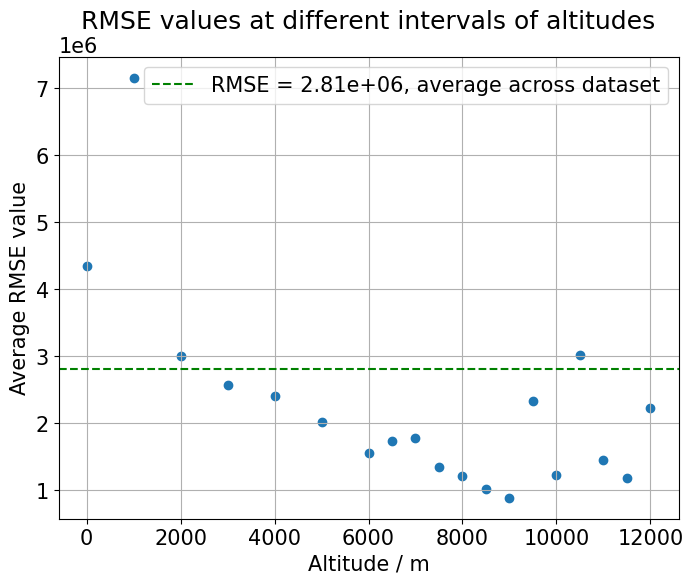

In [33]:
fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_rmse)
plt.axhline(y = (sklearn.metrics.root_mean_squared_error(df[["[OH]_measured"]], df["[OH]_calc"])), color = 'g', linestyle = '--', label =  f'RMSE = {'{:.2e}'.format(sklearn.metrics.root_mean_squared_error(df[["[OH]_measured"]], df["[OH]_calc"]))}, average across dataset')
plt.xlabel("Altitude / m")
plt.ylabel("Average RMSE value")
plt.title("RMSE values at different intervals of altitudes")
plt.legend(prop={'size':15})

plt.grid()

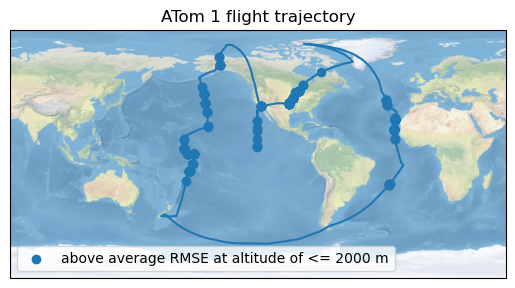

In [34]:
df["residual"] = np.nan
for i in range(len(df)):
    df.loc[i, "residual"] = abs(df.loc[i, "[OH]_measured"] - df.loc[i, "[OH]_calc"])
mask = (df["Altitude"] <= 2000) & (df["Altitude"] >= 0) & (df["residual"] > sklearn.metrics.root_mean_squared_error(df["[OH]_measured"], df["[OH]_calc"]).mean())

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=240))
ax.stock_img()
plt.rcParams.update({'font.size':10})
plt.plot(df["lon"], df["lat"], transform=ccrs.Geodetic())
plt.scatter(df["lon"][mask], df["lat"][mask], label="above average RMSE at altitude of <= 2000 m", transform=ccrs.Geodetic())
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.title("ATom 1 flight trajectory")
plt.legend()
plt.show()

r2 score for 2016-07-29: 0.356
RMSE for 2016-07-29: 2.34e+06 molecules cm^-3
r2 score for 2016-08-01: -27.928
RMSE for 2016-08-01: 5.19e+06 molecules cm^-3
r2 score for 2016-08-03: -0.256
RMSE for 2016-08-03: 1.50e+06 molecules cm^-3
r2 score for 2016-08-06: -0.221
RMSE for 2016-08-06: 1.45e+06 molecules cm^-3
r2 score for 2016-08-08: 0.068
RMSE for 2016-08-08: 1.53e+06 molecules cm^-3
r2 score for 2016-08-12: -0.135
RMSE for 2016-08-12: 3.38e+05 molecules cm^-3
r2 score for 2016-08-15: 0.063
RMSE for 2016-08-15: 1.07e+06 molecules cm^-3
r2 score for 2016-08-17: -0.06
RMSE for 2016-08-17: 2.38e+06 molecules cm^-3
r2 score for 2016-08-20: 0.36
RMSE for 2016-08-20: 1.73e+06 molecules cm^-3
r2 score for 2016-08-22: 0.21
RMSE for 2016-08-22: 1.49e+06 molecules cm^-3
r2 score for 2016-08-23: -4.49
RMSE for 2016-08-23: 7.02e+06 molecules cm^-3


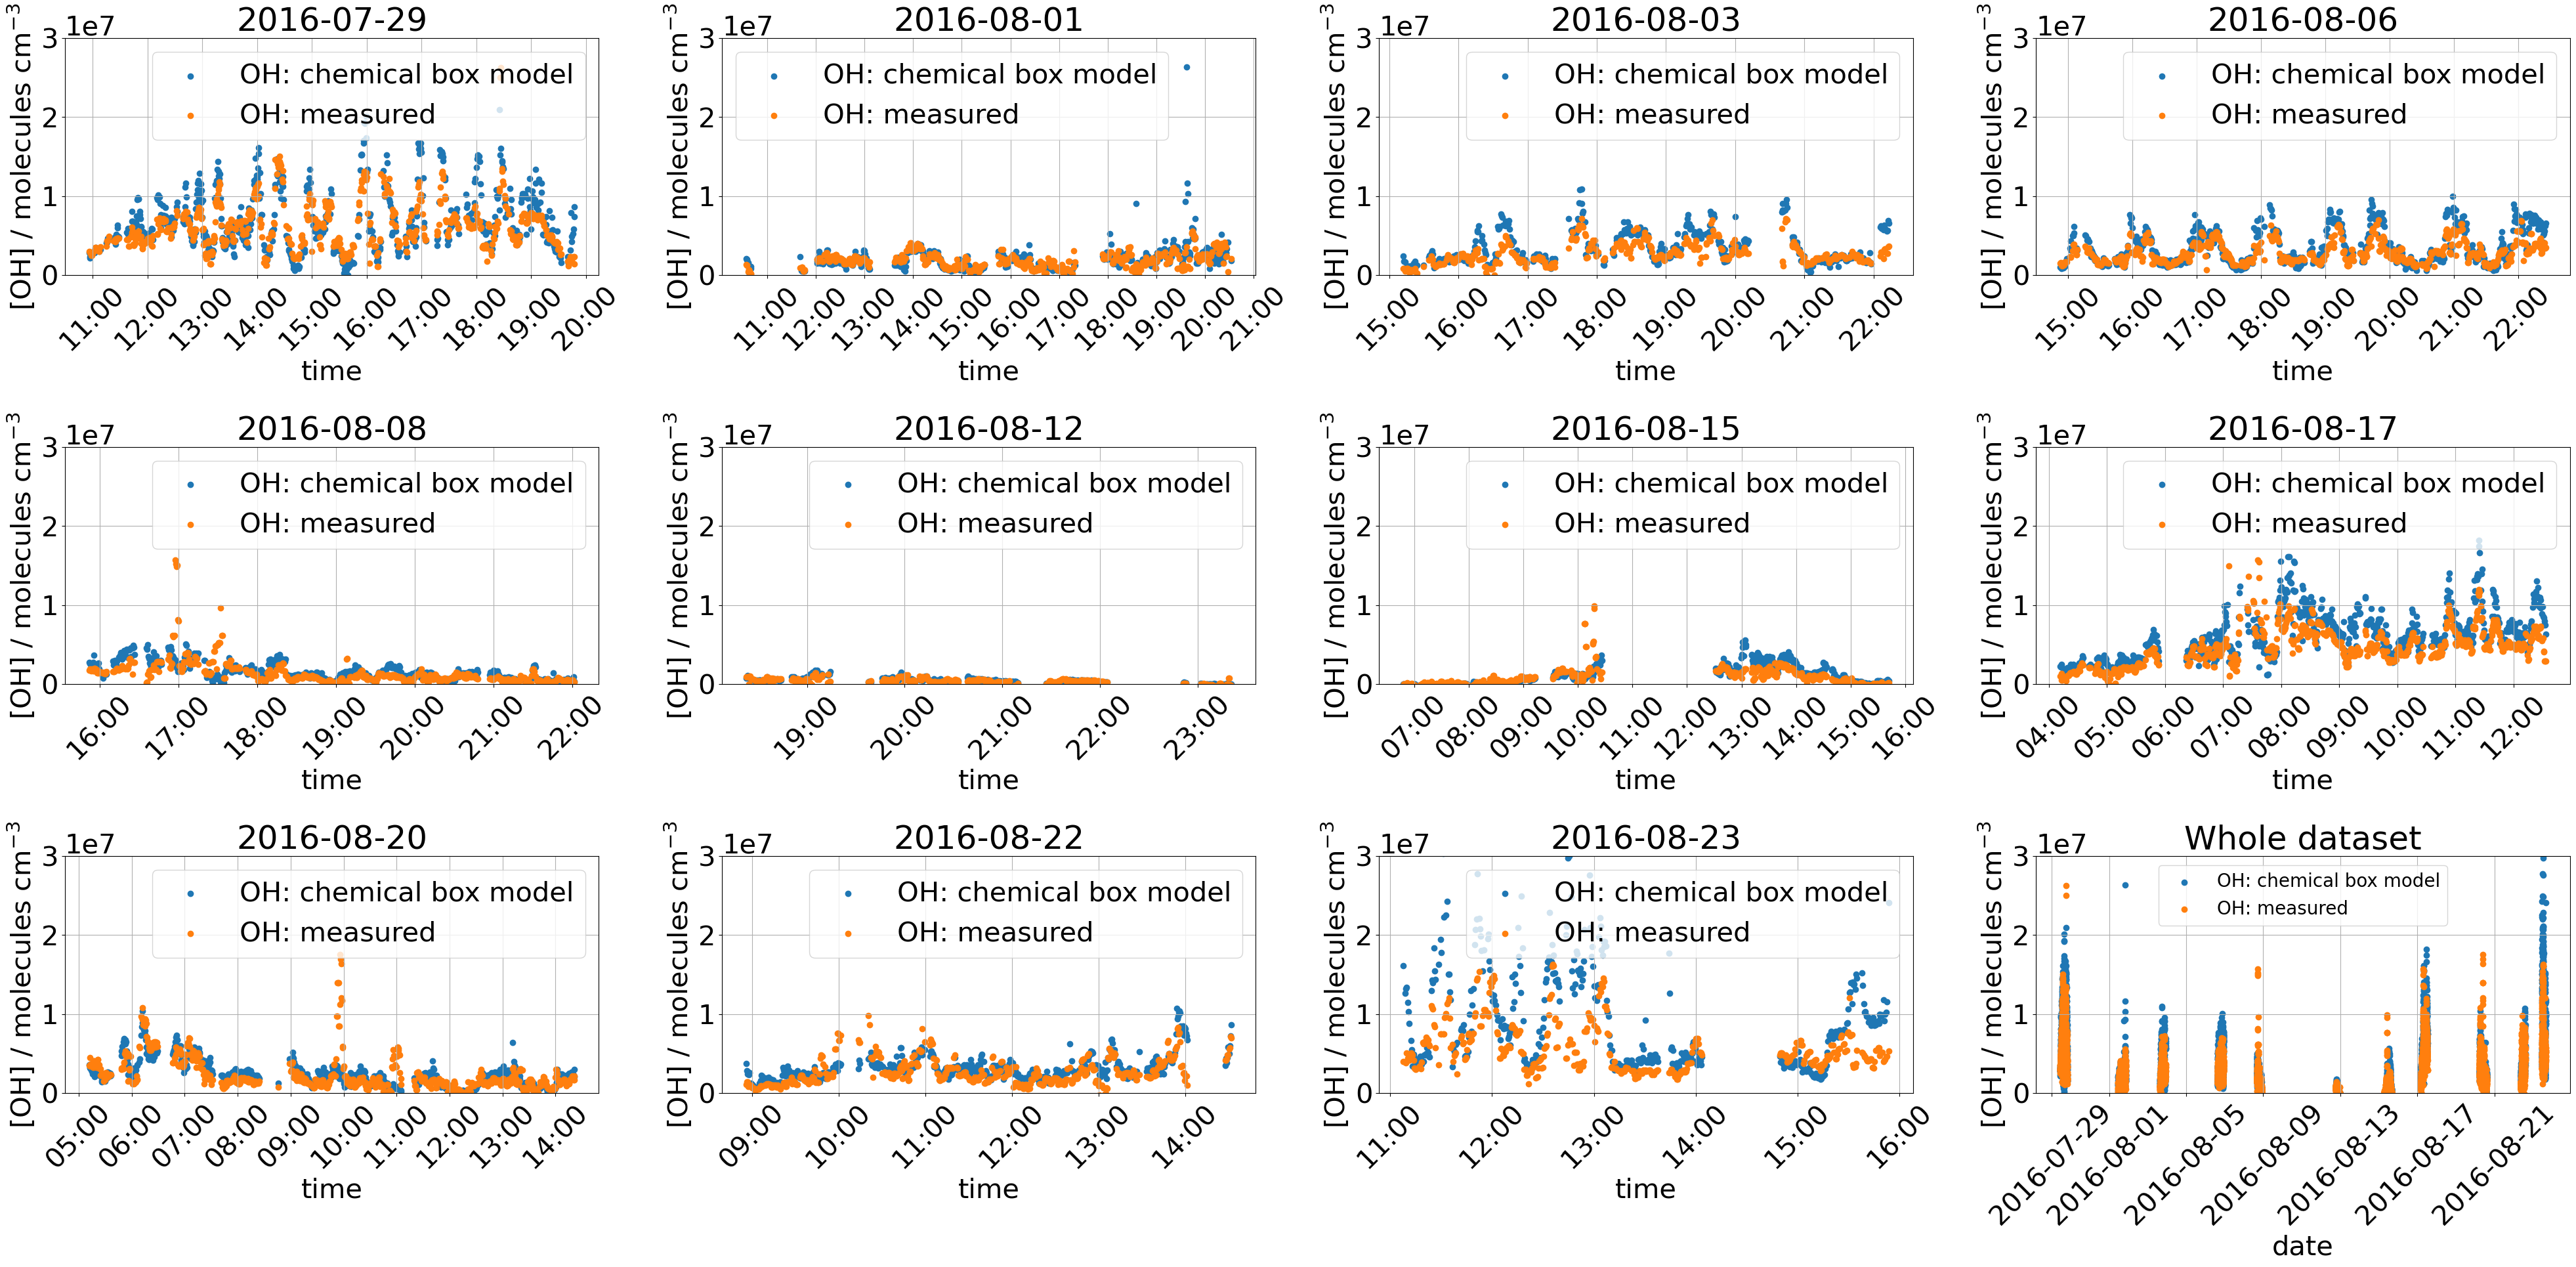

Overall r2 score was: -0.173
Overall RMSE was: 2.81e+06 molecules cm^-3


In [35]:
from sklearn.metrics import mean_squared_error
df["date_only"] = df["date"].dt.date
groups = list(df.groupby("date_only"))
# groups.append(0)
plt.rcParams.update({'font.size':30})
fig, axes = plt.subplots(3, 4, figsize=(40, 20), sharex=False, sharey=False)
axes = axes.flatten()  # Flatten to 1D array for easy indexing
plt.ylabel("[OH] / molecules cm$^{-3}$")

for i, (date, group) in enumerate(groups):
    if i >= 16:  # Limit to first 16 dates
        axes[i].scatter(df["date"], df["[OH]_calc"])
        break
    ax = axes[i]
    ax.scatter(group["date"], group["[OH]_calc"], label="OH: chemical box model")
    ax.scatter(group["date"], group["[OH]_measured"], label="OH: measured")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
    ax.set_title(str(date))
    ax.set_ylim(0, 3e7)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    ax.legend(fontsize=30)
    ax.set_xlabel("time")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
    ax.set_ylabel("[OH] / molecules cm$^{-3}$")

    X = group["[OH]_measured"]
    y = group["[OH]_calc"]
    print(f"r2 score for {date}: {round(sklearn.metrics.r2_score(X, y), 3)}")
    print(f"RMSE for {date}: {sklearn.metrics.root_mean_squared_error(X, y):.2e} molecules cm^-3")

ax = axes[-1]
ax.scatter(df["date"], df["[OH]_calc"], label="OH: chemical box model")
ax.scatter(df["date"], df["[OH]_measured"], label="OH: measured")
ax.set_title("Whole dataset")
ax.set_xlabel("date")
ax.set_ylim(0, 3e7)
ax.tick_params(axis='x', rotation=45)
ax.grid(True)
ax.legend(fontsize=8)

plt.legend(prop={'size':20})
plt.tight_layout()
plt.show()

print(f"Overall r2 score was: {round(sklearn.metrics.r2_score(df["[OH]_measured"], df["[OH]_calc"]), 3)}")
print(f"Overall RMSE was: {sklearn.metrics.root_mean_squared_error(df["[OH]_measured"], df["[OH]_calc"]):.2e} molecules cm^-3")

In [36]:
df.to_csv("box_model_additional_output.csv")

In [61]:
!jupyter --version

Selected Jupyter core packages...
IPython          : 9.10.0
ipykernel        : 7.2.0
ipywidgets       : 7.8.1
jupyter_client   : 8.8.0
jupyter_core     : 5.9.1
jupyter_server   : 2.14.1
jupyterlab       : 4.0.11
nbclient         : 0.8.0
nbconvert        : 7.10.0
nbformat         : 5.9.2
notebook         : 7.0.8
qtconsole        : 5.5.1
traitlets        : 5.14.3
